# Solution 4

## Tamir Cohen

### Q1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

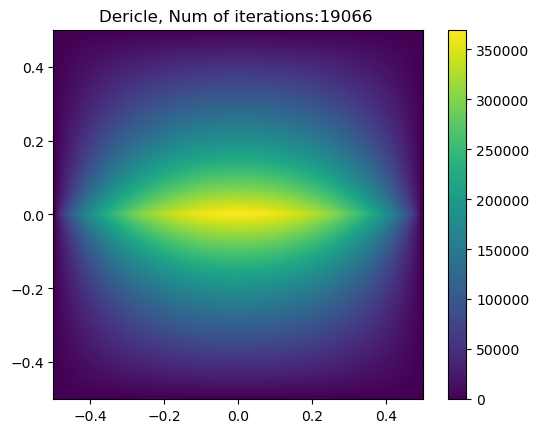

19066


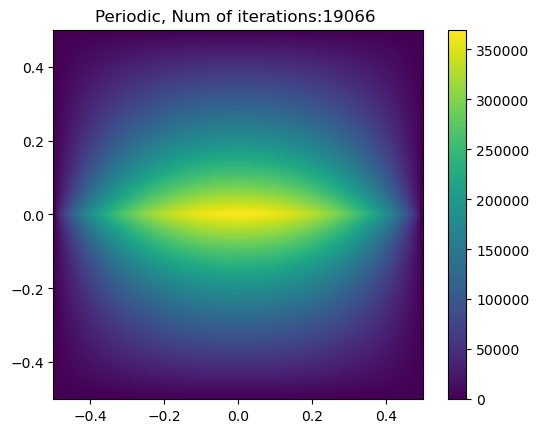

19066


In [34]:
def ghost_cell (phi,BC=0):
    # BC =0 dericle, BC = 1 periodic
    if BC == 0:
        phi_ =  np.zeros(np.array(phi.shape)+2)
        phi_[1:-1,1:-1] = phi.copy()
    
    elif BC == 1:
        phi_ =  np.zeros(np.array(phi.shape)+2)
        phi_[1:-1,1:-1] = phi.copy()
        phi_[0,:] = phi_[-2,:]
        phi_[-1,:] = phi_[1,:]
        phi_[:,0] = phi_[:,-2]
        phi_[:,-1] = phi_[:,1]
        
    
    return phi_

def err_fun(phi_prev,phi_new):
    # eps_max = np.sum(np.sum(np.abs(phi_new - phi_prev)))/len(phi_new)**2
    eps_max = np.max(np.max(np.abs(phi_new - phi_prev)**2))
    # print(np.max(phi_prev))
    # print(np.min((phi_new - phi_prev)**2))
    return eps_max


def  Poisson_func (phi=[],f=0, BC=0):
    Nx,Ny = np.array(phi.shape)
    x = np.linspace(-1/2,1/2,Nx+3)
    y = x = np.linspace(-1/2,1/2,Ny+3)
    N = Nx
    phi_= ghost_cell (phi, BC)
    # print(phi_.shape)
    f_  = ghost_cell (f, BC)
    # print(f_.shape)
    phi_new = phi_*0
    eps = 1;
    treshhold = 1e-1
    count = 0
    eps = err_fun(phi_,phi_new)
    while eps> treshhold:
        count+=1
        # phi_new = phi_*0
        for i in range(1,N+1):
            for j in range(1,N+1):
                phi_new[i,j] = 1/4 * (phi_[i+1,j] + phi_[i-1,j] + phi_[i,j+1] + phi_[i,j-1] + f_[i,j])
        eps = err_fun(phi_,phi_new)
        phi_ = phi_new.copy()
        # phi_ = ghost_cell(phi_[1:-1,1:-1])
        # phi_new = phi_*0
    plt.imshow(phi_,extent=[-1/2, 1/2, -1/2, 1/2]); plt.colorbar(); 
    if BC == 0 :
        plt.title (f'Dericle, Num of iterations:{count} ') 
    elif BC == 1:
        plt.title (f'Periodic, Num of iterations:{count} ') 
    plt.show()
    print (count)
    # print(phi_new)
    
def rho_mat_func(rho,N):
    N=N+1
    h = 1/(N+1)
    rho_norm = rho/h**2
    rho_mat= np.zeros([N,N]) # [raws,colmns]
    rho_mat[int(np.floor(N/2)),:] = rho_norm
    return rho_mat
    

def main(N = 2**5):
    phi0 = np.ones([N+1,N+1]) # [raws,colmns]
    rho = 1 #normlized to epsilon_0
    rho_mat = rho_mat_func(rho,N)
    BC = 0 # dericle
    Poisson_func (phi=phi0, f=rho_mat,BC=BC)
    BC = 1 # Periodic
    Poisson_func (phi=phi0, f=rho_mat,BC=BC)

if __name__ == "__main__":
    main()
    
    
    
    

### Q2

684


C:\Users\Tamir\AppData\Local\Temp\ipykernel_11492\2303467962.py:45: RuntimeWarning: divide by zero encountered in divide
  dt = C/dx_


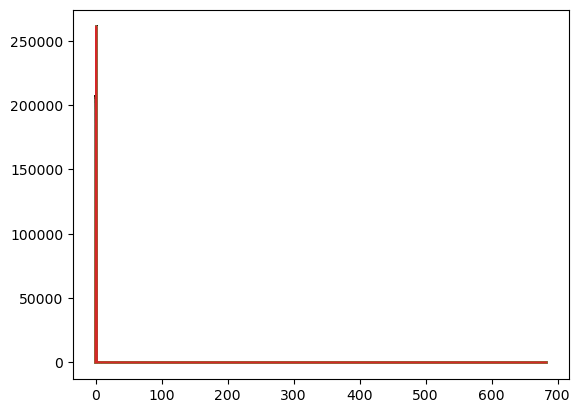

In [11]:
# plt_1 = plt.figure(1)   # handle to figure 1
# plt_2 = plt.figure(2)   # handle to figure 2
# plt_3 = plt.figure(3)   # handle to figure 2
# plt_4 = plt.figure(4)   # handle to figure 2

def step_func (Vec_len):
    N=Vec_len
    x = np.linspace(0.0, 1.0, N, endpoint=False)
    u = np.zeros_like(x)
    u[x < 0.5] = 2      # left state
    u[x >= 0.5] = 1   # right state
    return  u

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[0] = a[0]
    a_[-1]  = a[-1]
    return a_

    
def upwind(u,C,question="a"):
    u_ = goust_func(u)
  
    if "a" in question:
        u_new = u - C*u*(u_[1:-1] - u_[:-2])   # length N
        
    elif "b" in question:
        F = 0.5*u_**2
        u_new = u - C*(F[1:-1] - F[:-2])   # length N
    return u_new            


def shock_spead_calc(C, step, dx, dt):
    shock_pos = np.zeros_like(step)
    shock_vel = np.zeros_like(step)
    print(len(step))
    for i in range(len(step)):
        shock_pos[i] = np.min((np.where(np.abs((step[i][:-1] - step[i][1:] ))>0.3))[0])
        # print(np.min((np.where(np.abs((step[i][:-1] - step[i][1:] ))>0.3))[0]))
                # shock_pos[i] = np.where(np.abs((step[i][1:] - step[i][:-1] )))[0][0]
        # shock_pos[i] = shock_pos[i]
        dt = C/np.max(step)
        dx_ = shock_pos[i]-shock_pos[i-1]
        dt = C/dx_
        shock_vel[i] =   (shock_pos[i]-shock_pos[0])   / (dt*(i+1))
    return shock_vel


def uni_advection(C=0.5, N=2**6, u=1, question = "b"):

    dx = 1/N; T = 1/u; dt = C/np.abs(u) * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(int(len(t_vec)/3)):
        step_ = upwind(step[-1],C,question)
        # print (step_)
        step.append(step_)

    shock_vel = shock_spead_calc(C, step, dx, dt)
    
    return step, shock_vel



    # print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")

if uni_advection:
    N_vec = np.array([2**10])#,2**7,2**8
    shock_vel_a = [[] for _ in range(len(N_vec))]
    step_a  = [[] for _ in range(len(N_vec))]
    N=2**10
    i = 0
    step_a[i], shock_vel_a[i] = uni_advection(N = N, question = "a"); 
    plt.plot(shock_vel_a[0]);plt.show()
    
    # print(shock_vel_a[0])
    
    
    # for i in range(len(N_vec)):
    #     N = N_vec[i]
    #     step_a[i], shock_vel_a[i] = uni_advection(N = N, question = "a"); plt.show()
    # legend = list([])
    # for i in range(len(N_vec)):
    #     N = np.linspace(0,1,N_vec[i])
    #     plt.plot(shock_vel_a[i]); plt.xlim(0,10)
    #     legend.append(f"N = {N_vec[i]}")
    # plt.legend(legend)

    # shock_vel_b = [[] for _ in range(len(N_vec))]
    # step_b  = [[] for _ in range(len(N_vec))]
    # for i in range(len(N_vec)):
    #     N = N_vec[i]
    #     step_b[i], shock_vel_b[i] = uni_advection(N = N, question = "b"); plt.show()
    # legend = list([])
    
    # for i in range(len(N_vec)):
    #     plt.plot(shock_vel_b[i]); plt.xlim(0,10)
    #     legend.append(f"N = {N_vec[i]}")
    # plt.legend(legend)
    # plt.show()


    
    # uni_advection(N = 2**9, question = "a")
    # uni_advection(question = "b")        

    

In [7]:
# plt_1 = plt.figure(1)   # handle to figure 1
# plt_2 = plt.figure(2)   # handle to figure 2
# plt_3 = plt.figure(3)   # handle to figure 2
# plt_4 = plt.figure(4)   # handle to figure 2

def step_func (Vec_len):
    N=Vec_len
    # x = np.linspace(0, 1, Vec_len)  
    # y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    x = np.linspace(0.0, 1.0, N, endpoint=False)
    u = np.zeros_like(x)
    u[x < 0.5] = 2      # left state
    u[x >= 0.5] = 1   # right state
    return  u
    # return y

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[0] = a[0]
    a_[-1]  = a[-1]
    return a_

    
def upwind(u,C,question="a"):
    u_ = goust_func(u)
    S_ = S_func(u_)
    u_l_int = u_[1:]*0; u_r_int = u_[:-1]*0

    u_l_int[1:-1] = u[:-1]
    u_r_int[1:-1] = u[1: ] 

    u_l_int[ 0] = u[ 0]    ;  u_r_int[ 0] = u[ 0];
    u_l_int[-1] = u[-1]    ;  u_r_int[-1] = u[-1]; 

    u_int = np.zeros_like(u_l_int)     # length N+1
    for i in range(len(u_int)):
        ul = u_l_int[i]         # left of interface i+1/2
        ur = u_r_int[i]

        if ul > ur:               # shock
            if S_[i] > 0:
                u_int[i] = ul
            elif S_[i] < 0:
                u_int[i] = ur
            else:
                u_int[i] = 0
        else:                     # rarefaction
            if ul > 0:
                u_int[i] = ul
            elif ur < 0:
                u_int[i] = ur
            else:
                u_int[i] = 0


    if "a" in question:
        u_new = u - C*u*(u_int[1:] - u_int[0:-1])   # length N
        
    elif "b" in question:
        F = 0.5*u_int**2
        u_new = u - C*(F[1:] - F[:-1])   # length N
    

    return u_new            
                
            
    
    # if u>0:
    #     ai = a_[1:-1]; aii = a_[0:-2]
    # else:
    #     ai = a_[2:]; aii = a_[1:-1]
        
    # return ai - C*(ai-aii)




def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)

def uni_advection(C=0.5, N=2**6, u=1,plot_init=False,plot_mid=True,plot_end=False,question = "b"):
    dx = 1/N; T = 1/1000; dt = C/np.abs(u) * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    # if "a" in question:
    #     plt.figure(plt_1.number)
    # else:
    #     plt.figure(plt_3.number)
        
    for tt in range(int(N/2)):
        step_ = upwind(step[-1],C,question)
        step.append(step_)
        
        if tt%20 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); #plt. title (f't/T = %{t_vec[tt]/T*100:.2f}');# plt.show() 
        
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); #plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); #plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.tile (f"Method:{question}")
        # plt.show()
    # plt.show()

    # if "a" in question:
    #     plt.figure(plt_2.number)
    # else:
    #     plt.figure(plt_4.number)
    
    shock_pos = np.zeros_like(step)
    # print(shock_pos)
    shock_vel = np.zeros_like(step)
    for i in range(len(step)):
        # print(np.mean(np.where(np.abs((step[i][:-1] - step[i][1:] )))[0]))

        shock_pos[i] = np.min(np.where(np.abs((step[i][:-1] - step[i][1:] )))[0])
        shock_pos[i] = shock_pos[i]
        # shock_pos[i] = np.where(np.abs((step[i][1:] - step[i][:-1] )))[0][0]
        dt = C/dx/2
        # t = shock_pos[i])
        shock_vel[i] =   shock_pos[i] / (dt*i)
        # shock_vel = shock_vel/shock_vel[0]
        # print (shock_pos)
    # plt.plot(shock_vel); #plt.show()
    return step, shock_vel


    print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")

if uni_advection:
    N_vec = np.array([2**6,2**7,2**8])
    shock_vel_a = [[] for _ in range(len(N_vec))]
    step_a  = [[] for _ in range(len(N_vec))]
    for i in range(len(N_vec)):
        N = N_vec[i]
        step_a[i], shock_vel_a[i] = uni_advection(N = N, question = "a"); plt.show()
    legend = list([])
    for i in range(len(N_vec)):
        N = np.linspace(0,1,N_vec[i])
        # print(len(N))
        # print(len(shock_vel[i]))
        # print(len(step[i]))
        plt.plot(shock_vel[i]); plt.xlim(0,10)
        legend.append(f"N = {N_vec[i]}")
    plt.legend(legend)
    plt.show()

    shock_vel_b = [[] for _ in range(len(N_vec))]
    step_b  = [[] for _ in range(len(N_vec))]
    for i in range(len(N_vec)):
        N = N_vec[i]
        step_b[i], shock_vel_b[i] = uni_advection(N = N, question = "b"); plt.show()
    legend = list([])
    
    for i in range(len(N_vec)):
        plt.plot(shock_vel_b[i]); plt.xlim(0,10)
        legend.append(f"N = {N_vec[i]}")
    plt.legend(legend)
    plt.show()


    
    # uni_advection(N = 2**9, question = "a")
    # uni_advection(question = "b")        

    

NameError: name 'S_' is not defined

In [8]:

def step(x, a_vec, method, dx,dt):
    a_vec_new = a_vec*0
    if method == 1:     #du/dt + u*du/dx = 0
        for i in range(len(x)):
            a_vec_new[i+1] = a_vec[i+1] - (a_vec[i+1]-a_vec[i]) *a_vec[i+1]*dt/dx
    elif method == 2:   #du/dt + 0.5*du^2/dx = 0        
        for i in range(len(x)):
            a_vec_new[i+1] = a_vec[i+1] - (a_vec[i+1]**2-a_vec[i]**2) *0.5 *dt/dx 
    return a_vec_new
        
def upwind (method):
    CFL = 0.5  #= u*dt/dx
    # h = x[1]-x[0]
    # u = 0.1
    # dt = CFL *h/u
    # t_end = 1/u 
    
    t_list = [20,40,60] #,80]  #t_print
    
    #initial wave
    N = 64
    x = np.linspace(0,1,N)
    a_vec_0 = np.concatenate((2*np.ones(int(N/2)+1),np.ones(int(N/2)+1)))  
    
    CFL = 0.5  #= u*dt/dx
    dx = x[1]-x[0]
    dt = CFL*dx/np.max(a_vec_0)
    N_iterations = t_list[-1]  
    
    #measure shock velocity
    res_list = [0.99, 0.5, 0.01]
    inx_res1 = []; inx_res2 = []; inx_res3 = []
    inx_res_list = [inx_res1, inx_res2, inx_res3]
    
    a_vec = a_vec_0
    
    plt.figure()
    plt.title('advection - Upwind')
    plt.plot(x,a_vec_0[1:-1], label = 'initial')
    
    for n in range(N_iterations+1): 
        a_vec[0] = a_vec[2] #outflowing
        a_vec[1] = a_vec[2]
        a_vec[-1] = a_vec[-3]
        a_vec[-2] = a_vec[-3]
        
        a_vec_new = step(x, a_vec, method, dx,dt)
        a_vec = a_vec_new.copy()
        
        #velocity calc
        for i_res in range(len(res_list)):
            res = 1+res_list[i_res] 
            inx_res_i = inx_res_list[i_res]
            inx = np.where(a_vec<res)[0][1]
            inx_res_i.append(inx)
    
        if n in t_list:       
            plt.plot(x,a_vec_new[1:-1], label = f"N={n}")
            
            
    plt.legend()    
    plt.show()
    
    v_shock_list = []
    for i_list in range(len(inx_res_list)):
        inx_res_i = inx_res_list[i_list]
        d_inx_shock = np.array(inx_res_i[1:]) - inx_res_i[0]
        t = np.arange(len(d_inx_shock))+1
        v_shock = d_inx_shock/t
        
        v_shock_list.append(v_shock)
        plt.plot(range(N_iterations),v_shock, label=f"res={res_list[i_list]}")
    plt.legend()  
    plt.show()
    print(f"method {method} - v_shock =", v_shock_list[-1][-1])

upwind(method=1)   #a: du/dt + u*du/dx = 0
upwind(method=2)

SyntaxError: incomplete input (3870954451.py, line 78)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

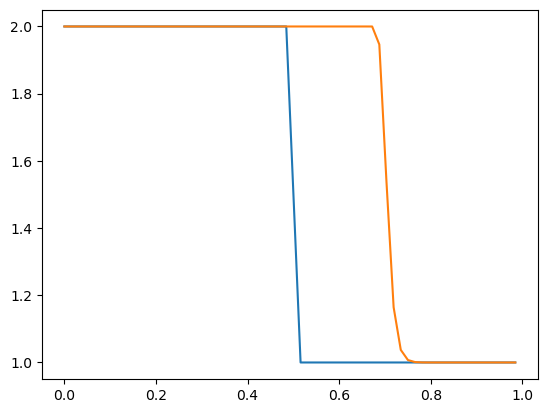

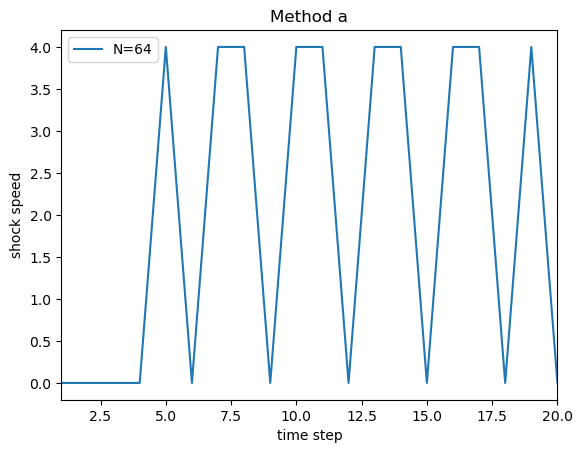

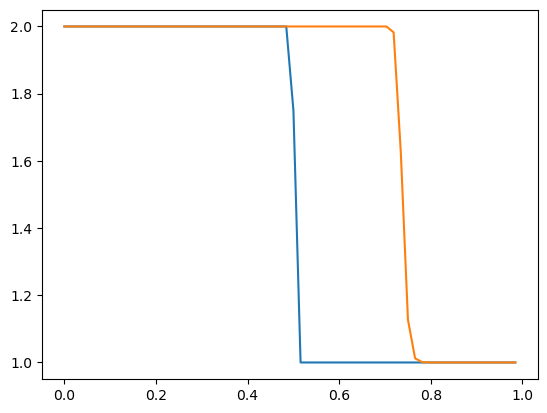

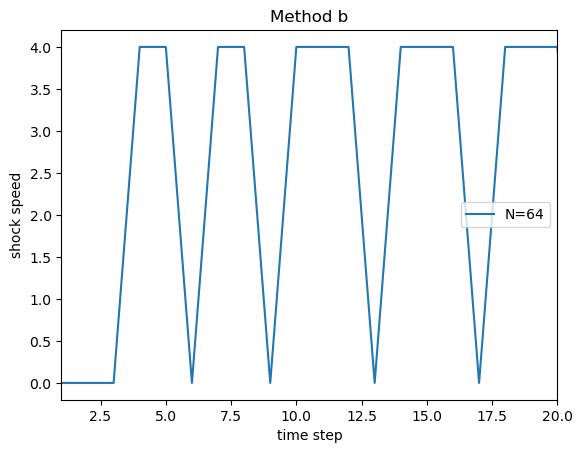

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt_1 = plt.figure(1)
plt_2 = plt.figure(2)
plt_3 = plt.figure(3)
plt_4 = plt.figure(4)

def step_func(Vec_len):
    N = Vec_len
    x = np.linspace(0.0, 1.0, N, endpoint=False)
    u = np.zeros_like(x)
    u[x < 0.5] = 2.0      # left state
    u[x >= 0.5] = 1.0     # right state
    return u

def goust_func(a):
    a_ = np.zeros(len(a)+2)
    a_[1:-1] = a
    a_[0]  = a[0]
    a_[-1] = a[-1]
    return a_

def S_func(u_vec):
    u_r = u_vec[:-1]
    u_l = u_vec[1:]
    return 0.5*(u_r + u_l)

def upwind(u, C, question="a"):
    u_ = goust_func(u)
    S_ = S_func(u_)
    u_l_int = u_[1:]*0
    u_r_int = u_[:-1]*0

    # first‑order reconstruction
    u_l_int[1:-1] = u[:-1]
    u_r_int[1:-1] = u[1:]

    u_l_int[0]  = u[0];   u_r_int[0]  = u[0]
    u_l_int[-1] = u[-1];  u_r_int[-1] = u[-1]

    # slide logic -> interface states u_int
    u_int = np.zeros_like(u_l_int)
    for i in range(len(u_int)):
        ul = u_l_int[i]
        ur = u_r_int[i]
        if ul > ur:                # shock
            if S_[i] > 0:
                u_int[i] = ul
            elif S_[i] < 0:
                u_int[i] = ur
            else:
                u_int[i] = 0.0
        else:                      # rarefaction
            if ul > 0:
                u_int[i] = ul
            elif ur < 0:
                u_int[i] = ur
            else:
                u_int[i] = 0.0

    if "a" in question:
        # du/dt + u*u_x = 0
        u_new = u - C*u*(u_int[1:] - u_int[:-1])
    elif "b" in question:
        # du/dt + (u^2/2)_x = 0
        F = 0.5*u_int**2
        u_new = u - C*(F[1:] - F[:-1])

    return u_new

# ---------- shock speed measurement ----------

def measure_shock_speed(step_history, dx, dt):
    nsteps = len(step_history)
    shock_pos = np.zeros(nsteps)
    shock_vel = np.zeros(nsteps)

    for n in range(nsteps):
        u = step_history[n]
        # first jump location
        jumps = np.where(np.abs(u[1:] - u[:-1]) > 1e-6)[0]
        if len(jumps) == 0:
            shock_pos[n] = np.nan
        else:
            i_shock = jumps[0]
            shock_pos[n] = (i_shock + 0.5)*dx  # physical position

        if n > 0 and not np.isnan(shock_pos[n]) and not np.isnan(shock_pos[n-1]):
            shock_vel[n] = (shock_pos[n] - shock_pos[n-1]) / dt
        else:
            shock_vel[n] = np.nan

    return shock_pos, shock_vel

# ------------- main driver -------------------

def uni_advection(C=0.5, N=2**6, u_max=2.0,
                  plot_mid=True, question="b"):
    dx = 1.0/N
    dt = C*dx/u_max
    nsteps = int(N/2)

    step_hist = []
    u = step_func(N)
    step_hist.append(u.copy())
    x_vec = np.linspace(0.0, 1.0, N, endpoint=False)

    for tt in range(nsteps):
        u = upwind(u, C, question)
        step_hist.append(u.copy())

        if plot_mid and (tt % 20 == 0):
            if "a" in question:
                plt.figure(plt_1.number)
            else:
                plt.figure(plt_3.number)
            plt.plot(x_vec, u)

    shock_pos, shock_vel = measure_shock_speed(step_hist, dx, dt)
    return step_hist, shock_pos, shock_vel

# run for several resolutions and plot velocities
if uni_advection:
    N_vec = np.array([2**6])

    # method a
    for i, N in enumerate(N_vec):
        _, _, v_a = uni_advection(N=N, question="a")
        plt.figure(plt_2.number)
        plt.plot(v_a, label=f"N={N}")
    plt.xlim(1, 20)
    plt.xlabel("time step")
    plt.ylabel("shock speed")
    plt.title("Method a")
    plt.legend()
    plt.show()

    # method b
    for i, N in enumerate(N_vec):
        _, _, v_b = uni_advection(N=N, question="b")
        plt.figure(plt_4.number)
        plt.plot(v_b, label=f"N={N}")
    plt.xlim(1, 20)
    plt.xlabel("time step")
    plt.ylabel("shock speed")
    plt.title("Method b")
    plt.legend()
    plt.show()
